In [2]:
# SLAM轨迹可视化

## 绘制运行轨迹图像
print("Hello World!")

Hello World!



Trajectory 1 (room):
  关键帧总数: 51
  轨迹总长度: 14.68 m
  起点坐标: (0.00, 0.00, 0.00)
  终点坐标: (1.74, -0.38, 0.45)

Trajectory 2 (room_4090):
  关键帧总数: 51
  轨迹总长度: 14.68 m
  起点坐标: (0.00, 0.00, 0.00)
  终点坐标: (1.74, -0.38, 0.45)

uncertainty_freiburg1_room_no_calib:
  关键帧总数: 53
  轨迹总长度: 16.70 m
  起点坐标: (0.00, 0.00, 0.00)
  终点坐标: (1.83, -0.39, 0.39)


/tmp/ipykernel_808701/4154060997.py:165: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_808701/4154060997.py:165: UserWarning: Glyph 36712 (\N{CJK UNIFIED IDEOGRAPH-8F68}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_808701/4154060997.py:165: UserWarning: Glyph 36857 (\N{CJK UNIFIED IDEOGRAPH-8FF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_808701/4154060997.py:165: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_808701/4154060997.py:165: UserWarning: Glyph 38190 (\N{CJK UNIFIED IDEOGRAPH-952E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_808701/4154060997.py:165: UserWarning: Glyph 24103 (\N{CJK UNIFIED IDEOGRAPH-5E27}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_808701/4154060997.py:165: UserWarning: Glyph 21644 (\N{CJK UN

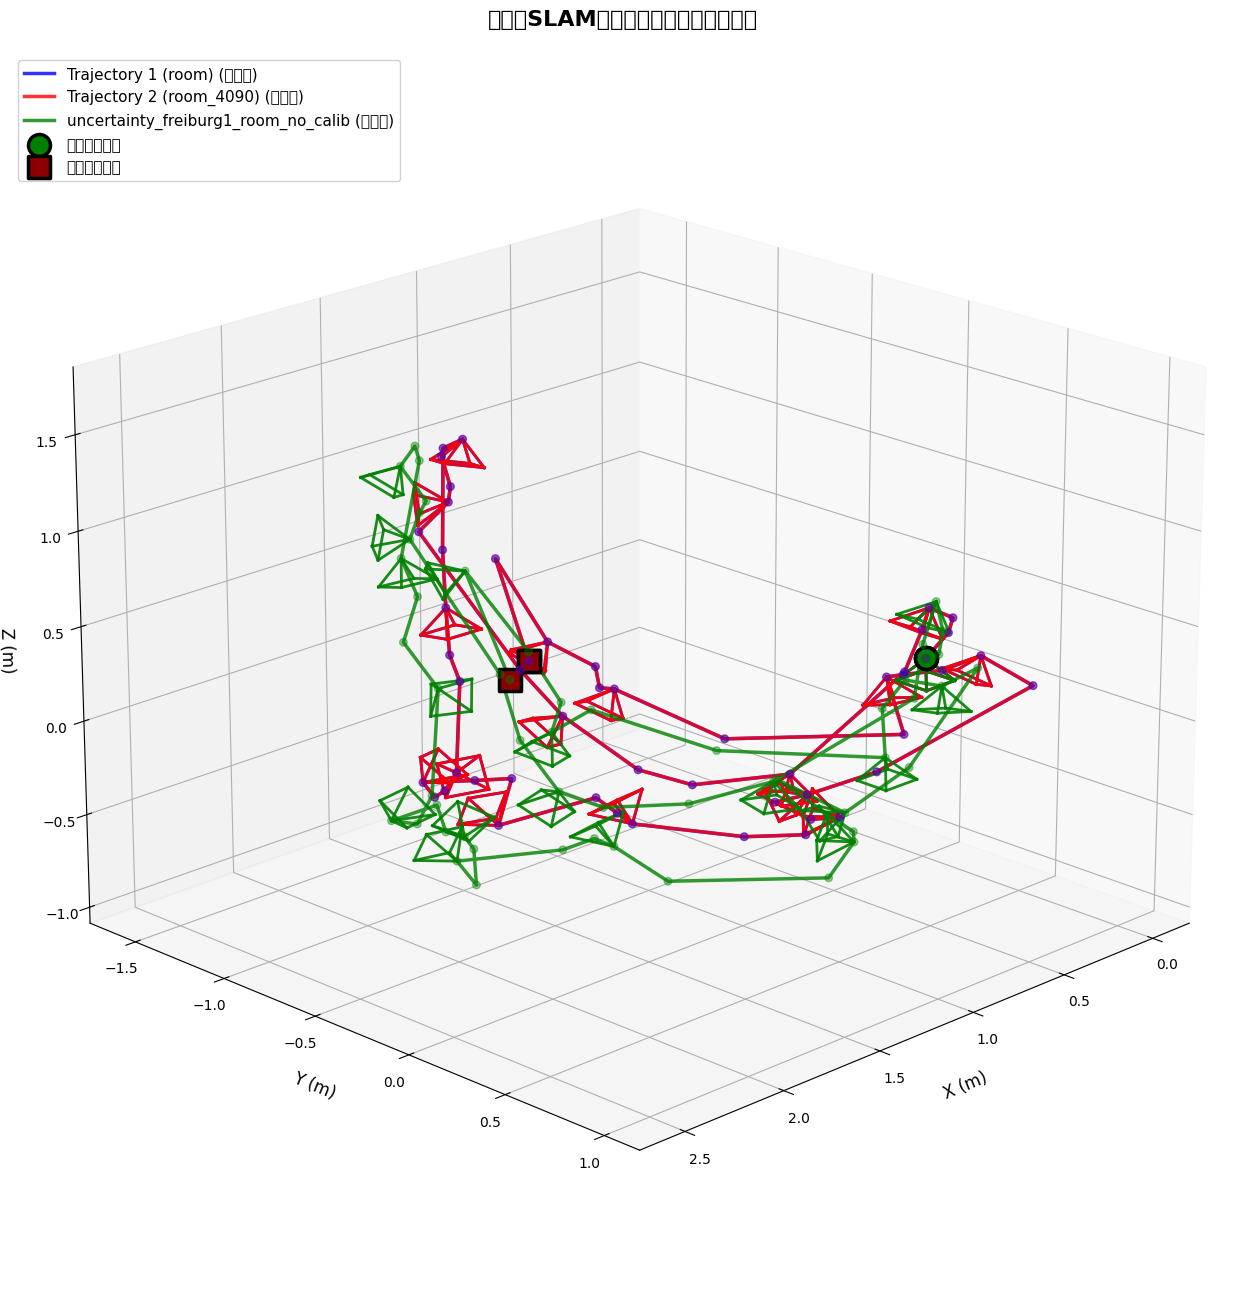

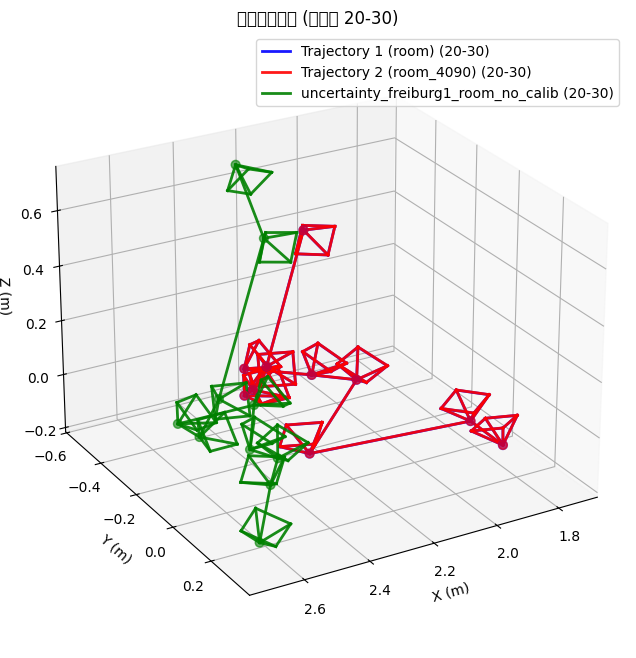

/home/zhuke/miniconda3/envs/mast3r/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhuke/miniconda3/envs/mast3r/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhuke/miniconda3/envs/mast3r/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhuke/miniconda3/envs/mast3r/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25237 (\N{CJK UNIFIED IDEOGRAPH-6295}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhuke/miniconda3/envs/mast3r/lib/python3.11/site-packages/IPython/core/pyl

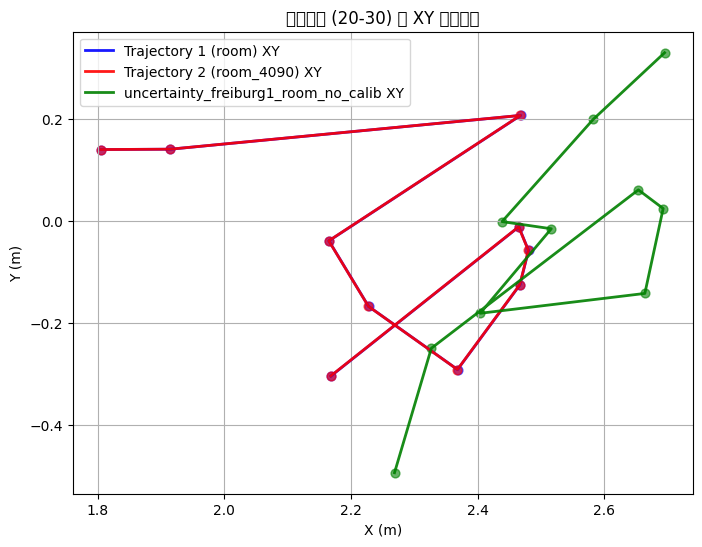

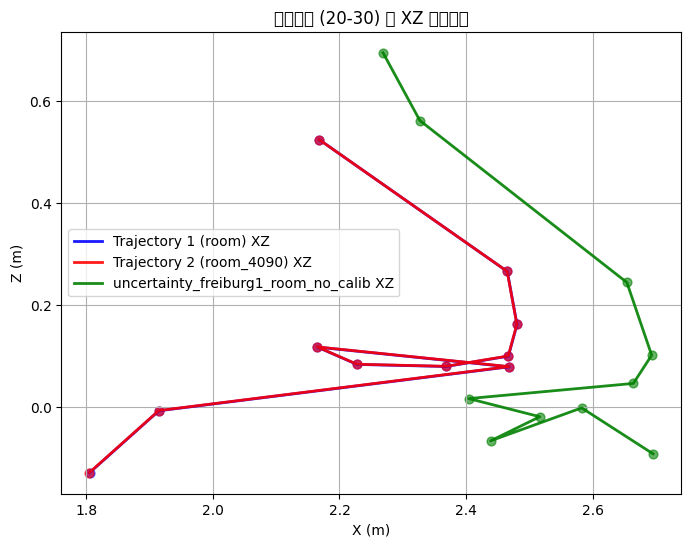

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.transform import Rotation as R
from pathlib import Path

# 读取轨迹文件
def load_trajectory(filename):
    """
    读取轨迹文件，返回位置和四元数
    格式: timestamp x y z qx qy qz qw
    """
    data = np.loadtxt(filename)
    timestamps = data[:, 0]
    positions = data[:, 1:4]  # x, y, z
    quaternions = data[:, 4:8]  # qx, qy, qz, qw
    return timestamps, positions, quaternions

# 绘制相机姿态（方框+四条射线）
def draw_camera(ax, position, rotation_matrix, scale=0.08, color='red'):
    """
    绘制相机姿态，包括一个方框和四条射线
    
    参数:
    - ax: matplotlib 3D axes
    - position: 相机位置 [x, y, z]
    - rotation_matrix: 3x3旋转矩阵
    - scale: 相机大小比例
    - color: 颜色
    """
    # 定义相机框架的5个顶点（相机坐标系）
    # 相机朝向-Z方向，Y向下，X向右
    camera_points = np.array([
        [0, 0, 0],           # 相机中心
        [-1, -1, -1.5],      # 左下角
        [1, -1, -1.5],       # 右下角
        [1, 1, -1.5],        # 右上角
        [-1, 1, -1.5],       # 左上角
    ]) * scale
    
    # 转换到世界坐标系
    world_points = (rotation_matrix @ camera_points.T).T + position
    
    # 绘制从相机中心到四个角的射线（红色粗实线）
    for i in range(1, 5):
        ax.plot3D(
            [world_points[0, 0], world_points[i, 0]],
            [world_points[0, 1], world_points[i, 1]],
            [world_points[0, 2], world_points[i, 2]],
            color=color, linewidth=2, linestyle='-', alpha=0.9
        )
    
    # 绘制方框的四条边（红色粗实线）
    edges = [(1, 2), (2, 3), (3, 4), (4, 1)]
    for start, end in edges:
        ax.plot3D(
            [world_points[start, 0], world_points[end, 0]],
            [world_points[start, 1], world_points[end, 1]],
            [world_points[start, 2], world_points[end, 2]],
            color=color, linewidth=2, linestyle='-', alpha=0.9
        )

# 多轨迹绘图函数
def plot_multiple_trajectories_with_cameras(trajectory_files, labels=None, colors=None, sample_rate=5):
    """
    在同一张图中绘制多条SLAM轨迹，包括位置点和相机姿态
    
    参数:
    - trajectory_files: 轨迹文件路径列表
    - labels: 每条轨迹的标签列表（可选）
    - colors: 每条轨迹的颜色列表（可选）
    - sample_rate: 相机绘制采样率（每N个关键帧绘制一个相机）
    """
    # 默认颜色列表
    if colors is None:
        colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'cyan']
    
    # 默认标签
    if labels is None:
        labels = [f'轨迹 {i+1}' for i in range(len(trajectory_files))]
    
    # 创建3D图形
    fig = plt.figure(figsize=(16, 13))
    ax = fig.add_subplot(111, projection='3d')
    
    # 用于计算所有轨迹的边界
    all_positions = []
    
    # 遍历每条轨迹
    for traj_idx, (traj_file, label, color) in enumerate(zip(trajectory_files, labels, colors)):
        # 读取数据
        timestamps, positions, quaternions = load_trajectory(traj_file)
        all_positions.append(positions)
        
        # 绘制轨迹线
        ax.plot3D(positions[:, 0], positions[:, 1], positions[:, 2], 
                  color=color, linewidth=2.5, label=f'{label} (轨迹线)', alpha=0.8)
        
        # 绘制位置点
        ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], 
                   c=color, marker='o', s=30, alpha=0.4)
        
        # 标记起点和终点
        ax.scatter(positions[0, 0], positions[0, 1], positions[0, 2], 
                   c='green', marker='o', s=250, edgecolors='black', linewidths=2.5,
                   zorder=100)
        ax.scatter(positions[-1, 0], positions[-1, 1], positions[-1, 2], 
                   c='darkred', marker='s', s=250, edgecolors='black', linewidths=2.5,
                   zorder=100)
        
        # 绘制相机姿态（每隔sample_rate个关键帧绘制一个）
        for i in range(0, len(positions), sample_rate):
            # 四元数转旋转矩阵 (qx, qy, qz, qw)
            quat = quaternions[i]
            # scipy的四元数格式是 (x, y, z, w)
            rotation = R.from_quat(quat)
            rotation_matrix = rotation.as_matrix()
            
            # 绘制相机（使用对应轨迹的颜色）
            draw_camera(ax, positions[i], rotation_matrix, scale=0.08, color=color)
        
        # 打印统计信息
        print(f"\n{label}:")
        print(f"  关键帧总数: {len(positions)}")
        print(f"  轨迹总长度: {np.sum(np.linalg.norm(np.diff(positions, axis=0), axis=1)):.2f} m")
        print(f"  起点坐标: ({positions[0, 0]:.2f}, {positions[0, 1]:.2f}, {positions[0, 2]:.2f})")
        print(f"  终点坐标: ({positions[-1, 0]:.2f}, {positions[-1, 1]:.2f}, {positions[-1, 2]:.2f})")
    
    # 添加起点和终点到图例
    ax.scatter([], [], c='green', marker='o', s=250, edgecolors='black', 
               linewidths=2.5, label='所有轨迹起点')
    ax.scatter([], [], c='darkred', marker='s', s=250, edgecolors='black', 
               linewidths=2.5, label='所有轨迹终点')
    
    # 设置标签和标题
    ax.set_xlabel('X (m)', fontsize=12, labelpad=10)
    ax.set_ylabel('Y (m)', fontsize=12, labelpad=10)
    ax.set_zlabel('Z (m)', fontsize=12, labelpad=10)
    ax.set_title('多轨迹SLAM关键帧轨迹和相机姿态对比', fontsize=16, pad=20, fontweight='bold')
    
    # 设置图例
    ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
    
    # 计算所有轨迹的边界，设置等比例坐标轴
    all_positions = np.concatenate(all_positions, axis=0)
    max_range = np.array([
        all_positions[:, 0].max() - all_positions[:, 0].min(),
        all_positions[:, 1].max() - all_positions[:, 1].min(),
        all_positions[:, 2].max() - all_positions[:, 2].min()
    ]).max() / 2.0
    
    mid_x = (all_positions[:, 0].max() + all_positions[:, 0].min()) * 0.5
    mid_y = (all_positions[:, 1].max() + all_positions[:, 1].min()) * 0.5
    mid_z = (all_positions[:, 2].max() + all_positions[:, 2].min()) * 0.5
    
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
    
    # 设置视角
    ax.view_init(elev=20, azim=45)
    
    # 添加网格
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    return fig, ax

figure_dir = Path("figure")
figure_dir.mkdir(exist_ok=True)

# 绘制多条轨迹
trajectory_files = [
    'logs/rgbd_dataset_freiburg1_room.txt',
    'logs/rgbd_dataset_freiburg1_room_4090.txt',
    'logs/rgbd_dataset_freiburg1_room_1127_2240_38.txt'
]

labels = [
    'Trajectory 1 (room)',
    'Trajectory 2 (room_4090)',
    'uncertainty_freiburg1_room_no_calib'
]

colors = ['blue', 'red', 'green']

fig, ax = plot_multiple_trajectories_with_cameras(
    trajectory_files, 
    labels=labels, 
    colors=colors, 
    sample_rate=3
)
fig.savefig(figure_dir / "trajectory_global.png", dpi=300, bbox_inches='tight')
plt.show()

# 绘制局部轨迹 (关键帧索引 20-30)
fig_local = plt.figure(figsize=(10, 8))
ax_local = fig_local.add_subplot(111, projection='3d')

for traj_file, label, color in zip(trajectory_files, labels, colors):
    _, positions, quats = load_trajectory(traj_file)
    idx_start, idx_end = 20, min(30, len(positions))
    segment = positions[idx_start:idx_end]
    ax_local.plot3D(segment[:, 0], segment[:, 1], segment[:, 2], color=color, linewidth=2, alpha=0.9, label=f'{label} (20-30)')
    ax_local.scatter(segment[:, 0], segment[:, 1], segment[:, 2], c=color, s=40, alpha=0.6)
    # 绘制局部相机姿态
    for i in range(idx_start, idx_end):
        quat = quats[i]
        rotation = R.from_quat(quat)
        rotation_matrix = rotation.as_matrix()
        draw_camera(ax_local, positions[i], rotation_matrix, scale=0.05, color=color)

ax_local.set_title('局部轨迹细节 (关键帧 20-30)')
ax_local.set_xlabel('X (m)'); ax_local.set_ylabel('Y (m)'); ax_local.set_zlabel('Z (m)')
ax_local.legend()
ax_local.view_init(elev=25, azim=60)
fig_local.savefig(figure_dir / "trajectory_local_3d.png", dpi=300, bbox_inches='tight')
plt.show()

# XY 平面投影
fig_xy, ax_xy = plt.subplots(figsize=(8, 6))
for traj_file, label, color in zip(trajectory_files, labels, colors):
    _, positions, _ = load_trajectory(traj_file)
    idx_start, idx_end = 20, min(30, len(positions))
    segment = positions[idx_start:idx_end]
    ax_xy.plot(segment[:, 0], segment[:, 1], color=color, linewidth=2, alpha=0.9, label=f'{label} XY')
    ax_xy.scatter(segment[:, 0], segment[:, 1], c=color, s=40, alpha=0.6)
ax_xy.set_title('局部轨迹 (20-30) 在 XY 平面投影')
ax_xy.set_xlabel('X (m)'); ax_xy.set_ylabel('Y (m)')
ax_xy.legend()
ax_xy.grid(True)
fig_xy.savefig(figure_dir / "trajectory_local_xy.png", dpi=300, bbox_inches='tight')
plt.show()

# XZ 平面投影
fig_xz, ax_xz = plt.subplots(figsize=(8, 6))
for traj_file, label, color in zip(trajectory_files, labels, colors):
    _, positions, _ = load_trajectory(traj_file)
    idx_start, idx_end = 20, min(30, len(positions))
    segment = positions[idx_start:idx_end]
    ax_xz.plot(segment[:, 0], segment[:, 2], color=color, linewidth=2, alpha=0.9, label=f'{label} XZ')
    ax_xz.scatter(segment[:, 0], segment[:, 2], c=color, s=40, alpha=0.6)
ax_xz.set_title('局部轨迹 (20-30) 在 XZ 平面投影')
ax_xz.set_xlabel('X (m)'); ax_xz.set_ylabel('Z (m)')
ax_xz.legend()
ax_xz.grid(True)
fig_xz.savefig(figure_dir / "trajectory_local_xz.png", dpi=300, bbox_inches='tight')
plt.show()


从你贴出的局部轨迹可以看出：绿色（未标定 + 不确定性权重）整体向正 Z 方向漂移、XY 也有偏移，而红色（论文原方法 + 标定）大致贴合原始轨迹。这种“一段段都往同一方向偏”的情况，往往不是“偶然更准确”，而是估计本身失去了正确的尺度/姿态约束，典型原因如下：
未标定引入的固有误差：TUM 房间序列自带精确内参，原方法在像素 + log 深度残差下运行；现在改成无标定模式后，残差变成归一化射线 + 距离，所有观测都被当成“单位焦距 + 无畸变”，会天然带来尺度和视差上的系统性偏差，尤其是相机前向/侧向移动时最明显。绿色曲线的整体抬升，很可能就是这一点导致的。
协方差 / 权重链路仍不稳定：从运行日志可以看到，仍有大量 “Cholesky failed / RELOCALIZING” 输出，说明自适应权重经常因为方差过小或有效残差不足而被迫回退甚至直接失效。这样一来，虽然我们“想”靠不确定性调整权重，但实际大部分帧要么退回常量权重，要么完全依赖重定位，从而产生断裂、漂移。
协方差先验过小：目前 Sigma = diag(0.02², 0.02², 0.08²) 对远距离点来说太乐观，传播后 Var_total 很容易趋近零，导致权重很大、GN Hessian 奇异。虽然我们加了 var_floor 等保护，但这只是在事后“刹车”，没有解决先验尺度失配的问题。结果就是绿色轨迹在某些方向上被过度拉伸。
传感器姿态初始化/重定位的差异：无标定模式在初始化时依赖 MASt3R 的单帧推理 + 归一化射线，这一套本身就比“用精确内参 + log 深度配准”弱；加上频繁的重定位，轨迹中段经常直接被 loop closure 的 Sim3 拉回别的关键帧，自然会出现整体平移或旋转。
因此，单从可视化来看，绿色轨迹并不是“更准确”，而是因为未标定 + 不稳定的权重机制引入了系统漂移。除了恢复标定模式，你还可以：
在无标定模式下仍引入近似内参（比如使用 TUM 提供的 K 但不进行全像素投影，仅用于归一化射线的尺度），减轻几何偏差。
让协方差随深度/置信度自适应，把 Sigma 的初值改成 diag((0.02+0.01z)^2, …, (0.08+0.04z)^2) 之类，让远处点权重不要那么激进。
在 tracker 中统计自适应权重的有效帧数，如果大部分时间都在 fallback，就先把“协方差权重”关掉，确认基线稳定后逐步放开。
对照 GT（TUM 全部有 ground truth），算一下 ATE/RPE：若绿色曲线误差反而更大，就说明当前的不确定性设计还没发挥作用，需要继续调参或回到标定残差。
总之，绿色轨迹的“整体漂移”是一个明显的不准确信号，更可能来源于未标定模式和协方差权重尚未稳定，而不是“更加准确”。建议先在有标定的条件下调好权重，确认效果显著后再尝试真正的无标定场景。

## 额外可视化选项

下面提供了一些额外的可视化功能：
- 多视角展示（正视图、侧视图、俯视图）
- 保存高清图片


In [ ]:
# 多视角展示
def plot_multi_view_trajectory(trajectory_file):
    """
    从多个视角展示轨迹
    """
    # 读取数据
    timestamps, positions, quaternions = load_trajectory(trajectory_file)
    
    # 创建包含4个子图的图形
    fig = plt.figure(figsize=(20, 15))
    
    # 1. 3D视图
    ax1 = fig.add_subplot(2, 2, 1, projection='3d')
    ax1.plot3D(positions[:, 0], positions[:, 1], positions[:, 2], 'b-', linewidth=2)
    ax1.scatter(positions[0, 0], positions[0, 1], positions[0, 2], c='green', s=200, marker='o', label='起点')
    ax1.scatter(positions[-1, 0], positions[-1, 1], positions[-1, 2], c='red', s=200, marker='o', label='终点')
    ax1.set_xlabel('X (m)')
    ax1.set_ylabel('Y (m)')
    ax1.set_zlabel('Z (m)')
    ax1.set_title('3D视图', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. XY平面俯视图
    ax2 = fig.add_subplot(2, 2, 2)
    ax2.plot(positions[:, 0], positions[:, 1], 'b-', linewidth=2, label='轨迹')
    ax2.scatter(positions[:, 0], positions[:, 1], c=range(len(positions)), cmap='RdYlGn_r', s=20, alpha=0.6)
    ax2.scatter(positions[0, 0], positions[0, 1], c='green', s=200, marker='o', label='起点', edgecolors='black', linewidths=2)
    ax2.scatter(positions[-1, 0], positions[-1, 1], c='red', s=200, marker='o', label='终点', edgecolors='black', linewidths=2)
    
    # 绘制相机方向箭头（俯视图）
    for i in range(0, len(positions), 5):
        quat = quaternions[i]
        rotation = R.from_quat(quat)
        rotation_matrix = rotation.as_matrix()
        # 相机朝向（-Z方向）
        direction = rotation_matrix @ np.array([0, 0, -0.3])
        ax2.arrow(positions[i, 0], positions[i, 1], direction[0], direction[1], 
                 head_width=0.05, head_length=0.05, fc='orange', ec='orange', alpha=0.5)
    
    ax2.set_xlabel('X (m)')
    ax2.set_ylabel('Y (m)')
    ax2.set_title('XY平面俯视图（带相机朝向）', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.axis('equal')
    
    # 3. XZ平面侧视图
    ax3 = fig.add_subplot(2, 2, 3)
    ax3.plot(positions[:, 0], positions[:, 2], 'b-', linewidth=2, label='轨迹')
    ax3.scatter(positions[:, 0], positions[:, 2], c=range(len(positions)), cmap='RdYlGn_r', s=30, alpha=0.6)
    ax3.scatter(positions[0, 0], positions[0, 2], c='green', s=200, marker='o', label='起点')
    ax3.scatter(positions[-1, 0], positions[-1, 2], c='red', s=200, marker='o', label='终点')
    ax3.set_xlabel('X (m)')
    ax3.set_ylabel('Z (m)')
    ax3.set_title('XZ平面侧视图', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.axis('equal')
    
    # 4. YZ平面侧视图
    ax4 = fig.add_subplot(2, 2, 4)
    ax4.plot(positions[:, 1], positions[:, 2], 'b-', linewidth=2, label='轨迹')
    ax4.scatter(positions[:, 1], positions[:, 2], c=range(len(positions)), cmap='RdYlGn_r', s=30, alpha=0.6)
    ax4.scatter(positions[0, 1], positions[0, 2], c='green', s=200, marker='o', label='起点')
    ax4.scatter(positions[-1, 1], positions[-1, 2], c='red', s=200, marker='o', label='终点')
    ax4.set_xlabel('Y (m)')
    ax4.set_ylabel('Z (m)')
    ax4.set_title('YZ平面侧视图', fontsize=14, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    ax4.axis('equal')
    
    plt.suptitle('SLAM轨迹多视角展示', fontsize=18, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    return fig

# 绘制多视角图
fig_multi = plot_multi_view_trajectory(trajectory_file)
plt.show()

# 可选：保存图片
# fig.savefig('logs/trajectory_3d.png', dpi=300, bbox_inches='tight')
# fig_multi.savefig('logs/trajectory_multi_view.png', dpi=300, bbox_inches='tight')
# print("图片已保存到 logs/ 目录")
